<a href="https://colab.research.google.com/github/jiyanshud22/Saltmine-Auto-Zoning-and-Stacking/blob/main/SuperBlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Zoning
             -Jiyanshu Dhaka

# Notation


let G is usable Grid


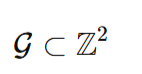

each cell is lattice point

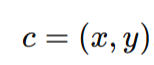

let
- $𝐴_{𝑘}$ denote set of cells belonging to anchor 𝑘.

- O denote occupied cells.

- Each block 𝑏 must be assigned a set of cells
$𝐶_{𝑏}$

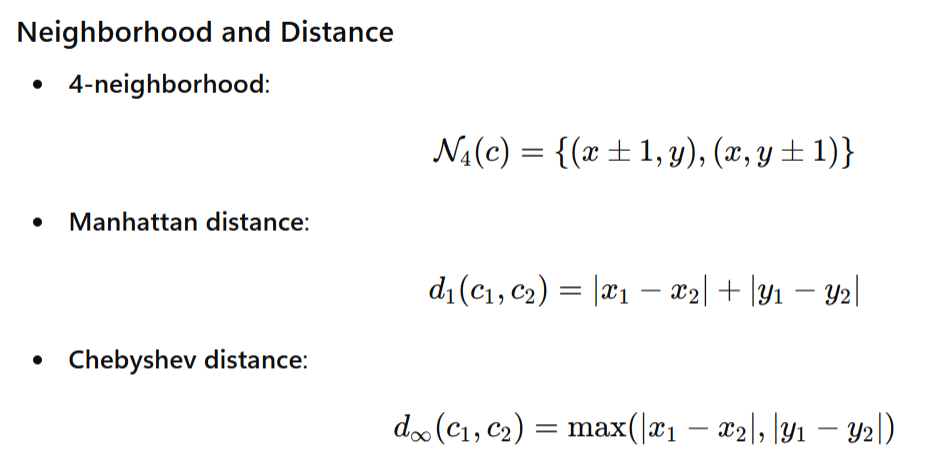



 .







 .









 .










 .








 .














 .


# Constarints

# Contiguity Constraint


- let 𝐶 is set of cell the it is contiguous iff graph is connected.

- this enforces each block occupies single connected component.

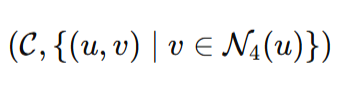

# Proximity Constraints

(𝑏,𝑎,$𝐷_{max}$)
- if block
𝑏 have set of Proximity constraints:


- here $𝐷_{max}$ will be given and $A_{a}$ is anchor





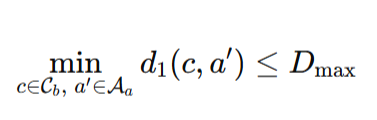




These are hard constraints.

soft proximity cost:

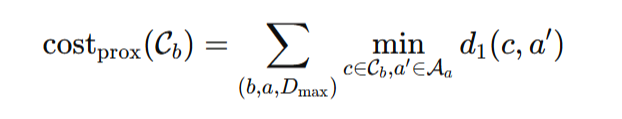


Smaller distance is preferred.

# Adjacency

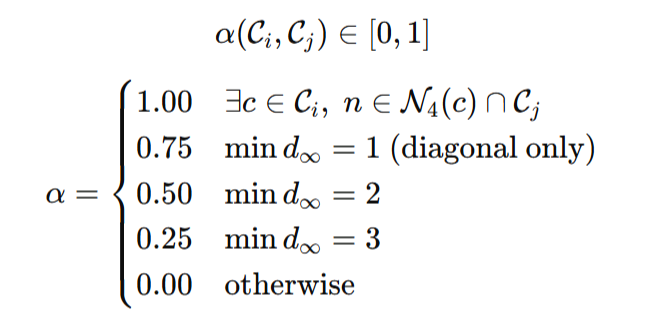

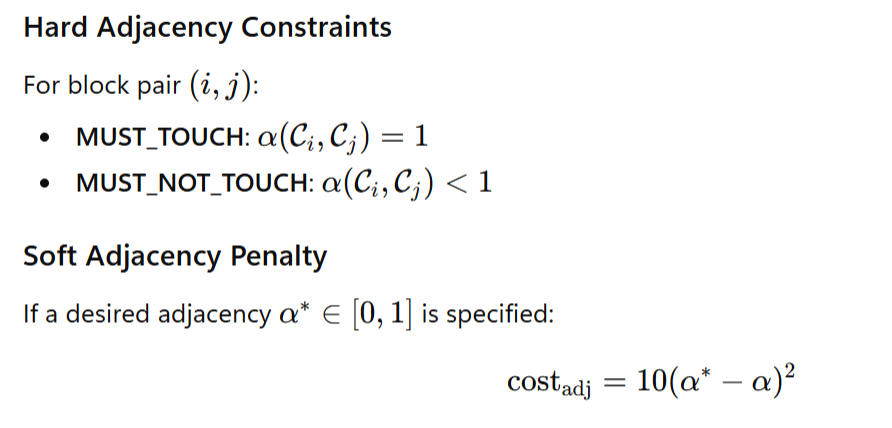



 .







 .









 .










 .








 .














 .


# Compactness Objective

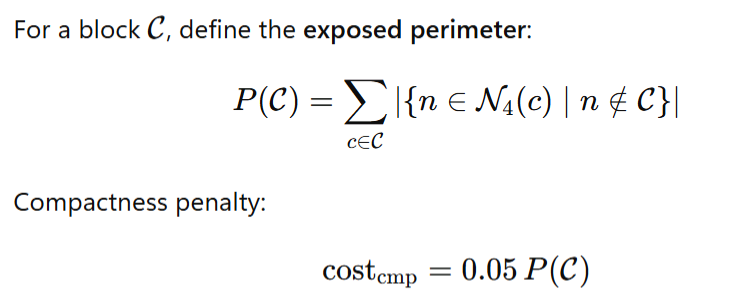

# Candidate Generation (Greedy Growth)

Step 1: Seed Selection

Pick starting cells that:

- Are free

- Are not anchors

- Already satisfy proximity constraints

This prunes the search very early.

Step 2: Greedy Growth

Starting from a seed:

- Grow cell-by-cell using 4-neighbors

- Always keep the shape contiguous

- Prefer cells closer to required anchors

- Stop when required area is reached

If growth fails → discard candidate.

This gives organic, compact shapes instead of random blobs.

# Hard Constraint Checking

Before scoring, candidates must:

- Avoid anchor cells

- Respect max distance to anchors

- Respect adjacency rules with already placed blocks

# Candidate Scoring Function

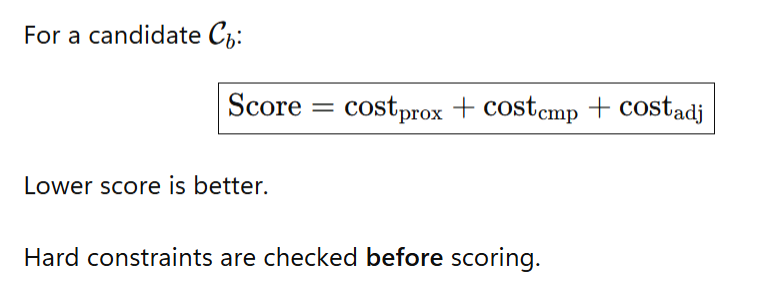

- **Proximity softness**

Closer to anchors = better

- **Compactness penalty**

Fewer exposed edges = better

- **Adjacency softness**

Penalize deviation from desired adjacency strength

# Top-K Filtering

For each block:

- Try many random growths

- Keep only the best K unique shapes

This is crucial:

- Prevents combinatorial explosion

- Keeps backtracking feasible

# Backtracking Solver

Strategy

1. Sort blocks by difficulty
(tight constraints + big area first)

2. Place blocks one by one

3. For each block:

- Try its top-K candidates

- Mark cells as occupied

- Recurse

4. If future block fails → backtrack

This is classic **DFS with constraint propagation.**



 .







 .









 .










 .








 .














 .


# Optimization Problem Summary

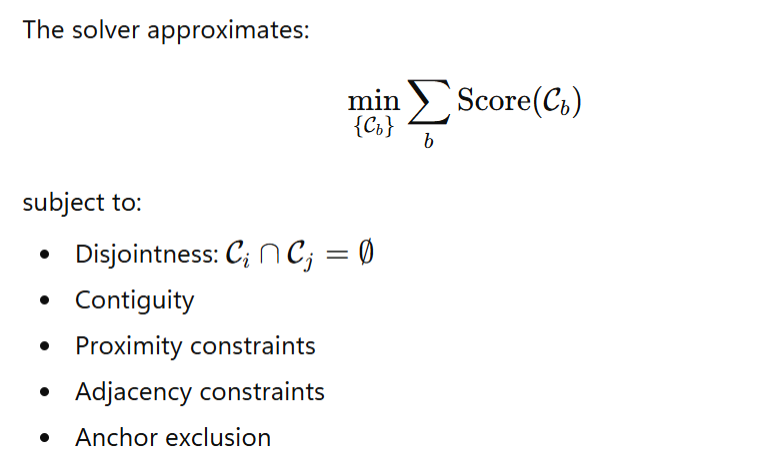

This is a constrained combinatorial optimization problem on a lattice, solved via heuristic candidate generation + depth-first backtracking.

In [1]:
# from __future__ import annotations
from dataclasses import dataclass
from collections import deque, defaultdict
import random
from typing import Dict, Set, Tuple, List, Optional, Iterable

Cell = Tuple[int, int]

# ----------------------------
# Core helpers
# ----------------------------

def manhattan(a: Cell, b: Cell) -> int:
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def neighbors4(c: Cell) -> List[Cell]:
    x, y = c
    return [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]

def adjacency_value(cells_a: Set[Cell], cells_b: Set[Cell]) -> float:
    """Return a granular adjacency strength between two cell-sets in [0.0, 1.0].

    Mapping (higher means stronger/closer adjacency):
    - 1.00 : Immediate / Abutting (side-touch, manhattan == 1)
    - 0.75 : Near (corner-touch, chebyshev == 1 but not side-touch)
    - 0.50 : Medium (chebyshev == 2)
    - 0.25 : Far (chebyshev == 3)
    - 0.00 : Neutral (chebyshev >= 4 or no cells)

    This gives a simple, interpretable scalar you can use for soft adjacency
    preferences. Keep `touches4` as a compatibility wrapper for legacy
    boolean checks (treats anything >= 0.9 as touching).
    """
    if not cells_a or not cells_b:
        return 0.0

    # fast check for side-adjacency (manhattan == 1) which we treat as 1.0
    for a in cells_a:
        for n in neighbors4(a):
            if n in cells_b:
                return 1.0

    # compute minimum Chebyshev distance between any pair
    min_cheb = min(max(abs(a[0]-b[0]), abs(a[1]-b[1])) for a in cells_a for b in cells_b)
    if min_cheb == 1:
        # corner-touch (diagonal) but not side-touch
        return 0.75
    if min_cheb == 2:
        return 0.50
    if min_cheb == 3:
        return 0.25
    return 0.0


def touches4(cells_a: Set[Cell], cells_b: Set[Cell]) -> bool:
    # backward-compatible boolean: treat strong adjacency as "touching"
    return adjacency_value(cells_a, cells_b) >= 0.9

def is_contiguous(cells: Set[Cell]) -> bool:
    if not cells:
        return False
    start = next(iter(cells))
    q = deque([start])
    seen = {start}
    while q:
        cur = q.popleft()
        for n in neighbors4(cur):
            if n in cells and n not in seen:
                seen.add(n)
                q.append(n)
    return len(seen) == len(cells)

def min_dist_to_anchor_cells(c: Cell, anchor_cells: Set[Cell]) -> int:
    # For tiny cases, brute force is fine. Later you’ll precompute a distance map.
    return min(manhattan(c, a) for a in anchor_cells)

def min_dist_set_to_anchor(cells: Set[Cell], anchor_cells: Set[Cell]) -> int:
    return min(min_dist_to_anchor_cells(c, anchor_cells) for c in cells)

# ----------------------------
# Constraints
# ----------------------------

@dataclass(frozen=True)
class ProximityConstraint:
    anchor: str
    max_dist: int
    mode: str = "all"  # keep for expansion; start with "all"

@dataclass(frozen=True)
class BlockSpec:
    block_id: str
    area: int
    proximity: List[ProximityConstraint]

# adjacency can be MUST_TOUCH or MUST_NOT_TOUCH for prototype
MUST_TOUCH = "MUST_TOUCH"
MUST_NOT_TOUCH = "MUST_NOT_TOUCH"

# adjacency_rules[("A","B")] = MUST_TOUCH or MUST_NOT_TOUCH (treat as undirected)
AdjRules = Dict[Tuple[str, str], str]

def norm_pair(a: str, b: str) -> Tuple[str, str]:
    return (a, b) if a <= b else (b, a)

# ----------------------------
# Candidate generation
# ----------------------------

def seed_candidates_for_block(
    usable: Set[Cell],
    occupied: Set[Cell],
    anchors: Dict[str, Set[Cell]],
    spec: BlockSpec,
) -> List[Cell]:
    """
    Returns possible seed cells that already satisfy proximity filters (fast prune).
    """
    # disallow anchor cells from being used for block placements
    anchor_cells = set()
    for ac in anchors.values():
        anchor_cells |= ac
    free = usable - occupied - anchor_cells
    if not spec.proximity:
        return list(free)

    seeds = []
    for c in free:
        ok = True
        for pc in spec.proximity:
            anchor_cells_for_pc = anchors[pc.anchor]
            if min_dist_to_anchor_cells(c, anchor_cells_for_pc) > pc.max_dist:
                ok = False
                break
        if ok:
            seeds.append(c)
    return seeds

def grow_cluster_greedy(
    seed: Cell,
    target_area: int,
    usable: Set[Cell],
    occupied: Set[Cell],
    anchors: Dict[str, Set[Cell]],
    spec: BlockSpec,
    rng: random.Random,
) -> Optional[Set[Cell]]:
    """
    Greedy contiguous growth. Replace this with your existing cluster growth if you want.
    Heuristic: expand frontier, prefer cells that keep proximity low (optional).
    """
    # disallow starting or growing onto anchor cells
    anchor_cells = set()
    for ac in anchors.values():
        anchor_cells |= ac

    if seed in occupied or seed not in usable or seed in anchor_cells:
        return None

    cluster = {seed}
    frontier = set(neighbors4(seed))

    while len(cluster) < target_area:
        # collect possible next cells
        candidates = [c for c in frontier if c in usable and c not in occupied and c not in cluster and c not in anchor_cells]
        if not candidates:
            return None

        # score candidates: prefer closer to required anchors (keeps cluster "pulled" to anchors)
        def cell_score(c: Cell) -> int:
            s = 0
            for pc in spec.proximity:
                s += min_dist_to_anchor_cells(c, anchors[pc.anchor])
            # tiny random tie-break to avoid determinism traps
            s = 10_000 * s + rng.randint(0, 50)
            return s

        candidates.sort(key=cell_score)
        nxt = candidates[0]

        cluster.add(nxt)
        frontier.remove(nxt)
        for n in neighbors4(nxt):
            if n not in cluster:
                frontier.add(n)

    # final contiguity should be guaranteed by construction, but keep check
    if not is_contiguous(cluster):
        return None
    return cluster

def candidate_score(
    cluster: Set[Cell],
    spec: BlockSpec,
    anchors: Dict[str, Set[Cell]],
    placements: Dict[str, Set[Cell]],
    adj_rules: AdjRules,
) -> float:
    """
    Lower is better.
    Hard violations should have been filtered, but scoring can rank soft preferences.
    """
    score = 0.0

    # Proximity softness: prefer being closer than required
    for pc in spec.proximity:
        d = min_dist_set_to_anchor(cluster, anchors[pc.anchor])
        # d <= max_dist guaranteed; reward smaller distance
        score += d

    # Compactness: lower perimeter is better
    # perimeter approx: count exposed sides
    exposed = 0
    for c in cluster:
        for n in neighbors4(c):
            if n not in cluster:
                exposed += 1
    score += 0.05 * exposed

    # Adjacency softness: if numeric preference provided, use squared difference
    bid = spec.block_id
    for other_id, other_cells in placements.items():
        rule = adj_rules.get(norm_pair(bid, other_id))
        if rule is None:
            continue
        # legacy hard rules preserved
        if rule == MUST_TOUCH:
            score += 0 if touches4(cluster, other_cells) else 1000  # should be filtered anyway
        elif rule == MUST_NOT_TOUCH:
            score += 0 if not touches4(cluster, other_cells) else 1000
        else:
            # numeric preference (soft): lower penalty when actual adjacency is close to desired
            try:
                desired = float(rule)
                actual = adjacency_value(cluster, other_cells)
                # scale penalty so that deviations matter but don't dominate small differences
                score += 10.0 * (desired - actual) ** 2
            except Exception:
                # if rule not parseable, ignore
                pass

    return score

def check_hard_constraints(
    cluster: Set[Cell],
    spec: BlockSpec,
    anchors: Dict[str, Set[Cell]],
    placements: Dict[str, Set[Cell]],
    adj_rules: AdjRules,
) -> bool:
    # disallow assigning any anchor cell to a cluster
    anchor_cells = set()
    for ac in anchors.values():
        anchor_cells |= ac
    if any(c in anchor_cells for c in cluster):
        return False

    # Proximity hard
    for pc in spec.proximity:
        d = min_dist_set_to_anchor(cluster, anchors[pc.anchor])
        if d > pc.max_dist:
            return False

    # Adjacency hard (only with already placed blocks)
    bid = spec.block_id
    for other_id, other_cells in placements.items():
        rule = adj_rules.get(norm_pair(bid, other_id))
        if rule == MUST_TOUCH and not touches4(cluster, other_cells):
            return False
        if rule == MUST_NOT_TOUCH and touches4(cluster, other_cells):
            return False

    return True

def generate_top_k_candidates(
    spec: BlockSpec,
    usable: Set[Cell],
    occupied: Set[Cell],
    anchors: Dict[str, Set[Cell]],
    placements: Dict[str, Set[Cell]],
    adj_rules: AdjRules,
    K: int = 20,
    tries_per_seed: int = 3,
    rng: Optional[random.Random] = None,
) -> List[Set[Cell]]:
    rng = rng or random.Random(0)

    seeds = seed_candidates_for_block(usable, occupied, anchors, spec)
    rng.shuffle(seeds)

    candidates_scored = []
    for seed in seeds:
        for _ in range(tries_per_seed):
            cluster = grow_cluster_greedy(seed, spec.area, usable, occupied, anchors, spec, rng)
            if not cluster:
                continue
            if not check_hard_constraints(cluster, spec, anchors, placements, adj_rules):
                continue
            sc = candidate_score(cluster, spec, anchors, placements, adj_rules)
            candidates_scored.append((sc, cluster))

    candidates_scored.sort(key=lambda t: t[0])
    # de-dup by frozenset
    seen = set()
    top = []
    for sc, cl in candidates_scored:
        key = frozenset(cl)
        if key in seen:
            continue
        seen.add(key)
        top.append(cl)
        if len(top) >= K:
            break
    return top

# ----------------------------
# Backtracking solver
# ----------------------------

def difficulty_key(spec: BlockSpec, anchors: Dict[str, Set[Cell]], usable: Set[Cell]) -> Tuple:
    # heuristic: tighter proximity & bigger area first
    tightness = sum(pc.max_dist for pc in spec.proximity) if spec.proximity else 10_000
    return (tightness, -spec.area, -len(spec.proximity))

def solve_layout_small(
    usable: Set[Cell],
    anchors: Dict[str, Set[Cell]],
    block_specs: List[BlockSpec],
    adj_rules: AdjRules,
    K: int = 20,
    rng_seed: int = 0,
    on_step=None,  # hook for your animation: on_step(placements, occupied, msg),
) -> Optional[Dict[str, Set[Cell]]]:
    rng = random.Random(rng_seed)

    # place hardest first
    specs = sorted(block_specs, key=lambda s: difficulty_key(s, anchors, usable))

    placements: Dict[str, Set[Cell]] = {}
    occupied: Set[Cell] = set()

    def backtrack(i: int) -> bool:
        if i == len(specs):
            return True

        spec = specs[i]
        cands = generate_top_k_candidates(
            spec, usable, occupied, anchors, placements, adj_rules, K=K, rng=rng
        )

        if on_step:
            on_step(placements, occupied, f"Block {spec.block_id}: {len(cands)} candidates")

        for idx, cl in enumerate(cands):
            placements[spec.block_id] = cl
            occupied_update = occupied | cl

            if on_step:
                on_step(placements, occupied_update, f"Place {spec.block_id} cand {idx+1}/{len(cands)}")

            old_occupied = occupied.copy()
            occupied.clear()
            occupied.update(occupied_update)

            if backtrack(i + 1):
                return True

            # undo
            occupied.clear()
            occupied.update(old_occupied)
            placements.pop(spec.block_id, None)

        return False

    ok = backtrack(0)
    return placements if ok else None


for 2D grid of cells.

Some cells are marked as anchors and cannot be used.

Each block must occupy:

- a fixed number of cells,

- all connected to each other,

- close to certain anchors (if specified).

What the solver does

1. Pick an order for blocks
Blocks with tighter requirements are handled first.

2. For one block at a time:

- Find starting cells that already satisfy distance rules.

- Grow a connected group of cells until the block’s required size is reached.

- Reject the group if it:

 overlaps anchors,
overlaps already placed blocks, violates adjacency rules.

3. Rank valid shapes
Prefer shapes that:

- are closer to required anchors,

- are more compact.

4. Try combinations

- Place one block,

- move to the next,

- if later blocks fail, undo and try a different shape.

**Result**

If a full placement satisfying all rules exists, it is returned.

Otherwise, the solver reports no solution.

In [2]:
def rect_usable(w, h):
    return {(x,y) for x in range(w) for y in range(h)}

usable = rect_usable(16, 12)

anchors = {
    "core": {(5,3), (5,4), (6,3), (6,4)},
    "entry": {(0,3), (0,4)},
    "facade": {(x,0) for x in range(16)} | {(x,11) for x in range(16)},
}

blocks = [
    BlockSpec("D1", area=10, proximity=[ProximityConstraint("core", 2)]),
    BlockSpec("D2", area=8,  proximity=[ProximityConstraint("entry", 2)]),
    BlockSpec("D3", area=6,  proximity=[ProximityConstraint("core", 3)]),
    BlockSpec("D4", area=6, proximity=[ProximityConstraint("core", 3)]),
    BlockSpec("D5", area=2, proximity=[ProximityConstraint("core", 3)]),
    BlockSpec("D6", area=4,  proximity=[ProximityConstraint("entry", 2)]),
    BlockSpec("D7", area=9,  proximity=[ProximityConstraint("facade", 1)]),
    BlockSpec("D8", area=4, proximity=[ProximityConstraint("core", 4)]),
    BlockSpec("D9", area=5,  proximity=[]),
    BlockSpec("D10", area=7, proximity=[ProximityConstraint("entry", 3)]),
    # add more if you need heavier tests
]

# Adjacency rules (undirected pair keys). Use MUST_TOUCH / MUST_NOT_TOUCH.
adj_rules = {
    # original prototypes
    norm_pair("D1","D3"): MUST_TOUCH,
    norm_pair("D2","D1"): MUST_NOT_TOUCH,
    # additional test rules
    # norm_pair("D4","D5"): MUST_TOUCH,
    # norm_pair("D4","D8"): MUST_NOT_TOUCH,
    # norm_pair("D5","D8"): MUST_TOUCH,
    # norm_pair("D7","D9"): MUST_TOUCH,
    # norm_pair("D6","D2"): MUST_NOT_TOUCH,
    norm_pair("D10","D2"): MUST_TOUCH,
}

sol = solve_layout_small(usable, anchors, blocks, adj_rules, K=30, rng_seed=7)
print("Solved:", sol is not None)
if sol:
    for k,v in sol.items():
        print(k, len(v))

Solved: True
D7 9
D1 10
D2 8
D6 4
D10 7
D3 6
D4 6
D5 2
D8 4
D9 5


In [3]:
def plot_layout(placements, usable, anchors=None, figsize=(6,6), cell_size=1, ax=None, show=True):
    """Plot a layout on a grid.
    - `placements`: dict mapping block_id -> set of (x,y) cells
    - `usable`: set of all usable (x,y) cells (used to compute bounds)
    - `anchors`: optional dict mapping anchor_name -> set of (x,y) cells   """
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    import matplotlib.colors as mcolors

    # compute bounds from usable cells
    xs = [c[0] for c in usable] if usable else [0]
    ys = [c[1] for c in usable] if usable else [0]
    minx, maxx = min(xs), max(xs)
    miny, maxy = min(ys), max(ys)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True

    ax.set_xlim(minx - 0.5, maxx + 0.5)
    ax.set_ylim(miny - 0.5, maxy + 0.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(minx, maxx + 1))
    ax.set_yticks(range(miny, maxy + 1))
    ax.grid(True, color='lightgray', linewidth=0.5)

    # color map for blocks
    block_ids = sorted(placements.keys()) if placements else []
    cmap = plt.get_cmap('tab20')
    colors = {bid: cmap(i % 20) for i, bid in enumerate(block_ids)}

    # draw usable cells faintly
    for (x, y) in usable:
        ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor='none', edgecolor='#eeeeee'))

    # draw placed blocks
    for bid, cells in placements.items():
        col = colors.get(bid, (0.7, 0.7, 0.7, 1.0))
        for (x, y) in cells:
            ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor=col, edgecolor='black', linewidth=0.6))
        # annotate block id at centroid
        if cells:
            cx = sum(c[0] for c in cells) / len(cells)
            cy = sum(c[1] for c in cells) / len(cells)
            ax.text(cx, cy, bid, ha='center', va='center', fontsize=8, color='black')

    # draw anchors if provided
    if anchors:
        for aname, acells in anchors.items():
            # pick a marker color contrasting with blocks
            ax.scatter([c[0] for c in acells], [c[1] for c in acells], marker='s', s=120, facecolors='none', edgecolors='red', linewidths=1.0, label=f'anchor:{aname}')

    # Legend for blocks (show one patch per block id)
    from matplotlib.lines import Line2D
    legend_items = []
    for bid in block_ids:
        legend_items.append(Line2D([0], [0], marker='s', color='w', label=bid, markerfacecolor=colors[bid], markersize=10, markeredgecolor='black'))
    if anchors:
        legend_items.append(Line2D([0], [0], marker='s', color='w', label='anchor', markerfacecolor='none', markeredgecolor='red', markersize=10))
    if legend_items:
        ax.legend(handles=legend_items, bbox_to_anchor=(1.02, 1), loc='upper left')

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.invert_yaxis()

    if show and created_fig:
        plt.show()
    return ax

# Example: call with `plot_layout(sol, usable, anchors)` after solving`

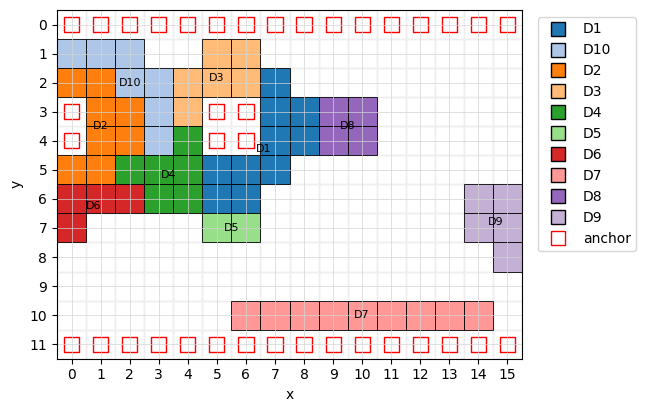

In [4]:
# Run this in the notebook after the solver cell
if sol is None:
    print("No solution found")
else:
    # simple display
    plot_layout(sol, usable, anchors)

    # optional: get Axes to save or tweak
    # ax = plot_layout(sol, usable, anchors, show=False)
    # ax.figure.savefig("layout.png", dpi=200, bbox_inches="tight")

In [5]:
def reshape_to_rectangular(placements, usable, anchors=None, max_extra_area=8):
    """Try to replace each assigned cluster with a more rectangular cluster of the same area.
    Preference: prefer squarish rectangles (minimize |w-h|) and proximity to original centroid.
    Strategy: search for candidate rectangles, score them by squareness and distance to centroid, and pick the best.
    For larger rectangles, try multiple seeds inside the rect to find a contiguous subset of size n and score those subsets.
    Special case: if the only exact rectangles for area n are very skewed (lines), prefer searching larger areas to find squarish subsets.
    Returns a new placements dict (falls back to original cluster when no rectangle is found).
    """
    anchors = anchors or {}
    anchor_cells = set().union(*anchors.values()) if anchors else set()
    # grid bounds from usable
    xs = [c[0] for c in usable] if usable else [0]
    ys = [c[1] for c in usable] if usable else [0]
    minx, maxx = min(xs), max(xs)
    miny, maxy = min(ys), max(ys)

    def exposed_sides(cells: Set[tuple]) -> int:
        s = 0
        for c in cells:
            for n in neighbors4(c):
                if n not in cells:
                    s += 1
        return s

    # helper: factor pairs for area constrained by grid size (return squarish-first order)
    def factor_pairs(area, max_w, max_h):
        pairs = []
        for w in range(1, int(area**0.5) + 1):
            if area % w != 0:
                continue
            h = area // w
            if w <= max_w and h <= max_h:
                pairs.append((w, h))
            if h <= max_w and w <= max_h and h != w:
                pairs.append((h, w))
        # sort by squareness then by smaller perimeter (most square, then compact)
        pairs = sorted(set(pairs), key=lambda p: (abs(p[0]-p[1]), p[0]*p[1], max(p)))
        return pairs

    # helper: get contiguous n cells inside a rect by trying multiple seeds (prefer list ordered by centroid closeness)
    def pick_contiguous_within(rect, n, prefer=None, tries=8):
        from collections import deque
        candidates = set(rect)
        seeds = []
        if prefer and prefer in candidates:
            seeds.append(prefer)
        centroid = prefer if prefer else (sum(c[0] for c in rect)/len(rect), sum(c[1] for c in rect)/len(rect))
        sorted_by_dist = sorted(candidates, key=lambda c: (c[0]-centroid[0])**2 + (c[1]-centroid[1])**2)
        for s in sorted_by_dist:
            if s not in seeds:
                seeds.append(s)
            if len(seeds) >= tries:
                break

        def bfs_from(start):
            q = deque([start])
            seen = {start}
            while q and len(seen) < n:
                cur = q.popleft()
                for nb in [(cur[0]+1,cur[1]),(cur[0]-1,cur[1]),(cur[0],cur[1]+1),(cur[0],cur[1]-1)]:
                    if nb in candidates and nb not in seen:
                        seen.add(nb)
                        q.append(nb)
                        if len(seen) >= n:
                            break
            if len(seen) == n and is_contiguous(seen):
                return seen
            return None

        for s in seeds:
            subset = bfs_from(s)
            if subset is not None:
                return subset
        return None

    def rect_centroid_dist(rect, centroid):
        rcx = (min(x for x,_ in rect) + max(x for x,_ in rect)) / 2
        rcy = (min(y for _,y in rect) + max(y for _,y in rect)) / 2
        return (rcx - centroid[0])**2 + (rcy - centroid[1])**2

    new_placements = {}
    occupied_global = set()
    for bid, cells in placements.items():
        occupied_global |= cells

    for bid, cells in placements.items():
        n = len(cells)
        occ_other = occupied_global - set(cells)
        found = None
        centroid = (sum(c[0] for c in cells)/n, sum(c[1] for c in cells)/n)
        max_w = maxx - minx + 1
        max_h = maxy - miny + 1

        # 1) Try exact-area rectangles; collect candidates and pick best by score
        candidates_rects = []
        for (w, h) in factor_pairs(n, max_w, max_h):
            for x0 in range(minx, maxx - w + 2):
                for y0 in range(miny, maxy - h + 2):
                    rect = {(x,y) for x in range(x0, x0+w) for y in range(y0, y0+h)}
                    if not rect <= usable:
                        continue
                    if rect & anchor_cells:
                        continue
                    if rect & occ_other:
                        continue
                    score = (abs(w-h), rect_centroid_dist(rect, centroid), exposed_sides(rect))
                    candidates_rects.append((score, rect, (w,h)))
        # determine if exact rectangles are acceptable (not just thin lines)
        best_exact = None
        if candidates_rects:
            candidates_rects.sort(key=lambda t: t[0])
            best_exact = candidates_rects[0]
            # if best_exact is not too skewed (squareness <= 1), accept it; otherwise continue to search larger areas
            if best_exact[2] and abs(best_exact[2][0] - best_exact[2][1]) <= 1:
                found = best_exact[1]

        if found:
            new_placements[bid] = found
            occupied_global -= set(cells)
            occupied_global |= found
            continue

        # 2) Try slightly larger rectangles and pick best subset inside them (score subset by bounding-box squareness + subset perimeter)
        candidates_subsets = []
        for area in range(n+1, n + max_extra_area + 1):
            for (w, h) in factor_pairs(area, max_w, max_h):
                for x0 in range(minx, maxx - w + 2):
                    for y0 in range(miny, maxy - h + 2):
                        rect = {(x,y) for x in range(x0, x0+w) for y in range(y0, y0+h)}
                        if not rect <= usable:
                            continue
                        if rect & anchor_cells:
                            continue
                        if rect & occ_other:
                            continue
                        prefer_seed = min(rect, key=lambda c: (c[0]-centroid[0])**2 + (c[1]-centroid[1])**2)
                        subset = pick_contiguous_within(rect, n, prefer=prefer_seed, tries=12)
                        if subset is not None:
                            sx = [c[0] for c in subset]
                            sy = [c[1] for c in subset]
                            bw = max(sx)-min(sx)+1
                            bh = max(sy)-min(sy)+1
                            subset_score = (abs(bw-bh), rect_centroid_dist(rect, centroid), exposed_sides(subset))
                            candidates_subsets.append((subset_score, subset, (w,h)))
        if candidates_subsets:
            candidates_subsets.sort(key=lambda t: t[0])
            found = candidates_subsets[0][1]
        # If no good larger subset found but an exact rect exists (even if skewed), use exact rect as fallback
        if not found and best_exact is not None:
            found = best_exact[1]
        if found:
            new_placements[bid] = found
            occupied_global -= set(cells)
            occupied_global |= found
        else:
            new_placements[bid] = cells
    return new_placements

# Example usage: after solving, call:
# sol2 = reshape_to_rectangular(sol, usable, anchors)
# plot_layout(sol2, usable, anchors)

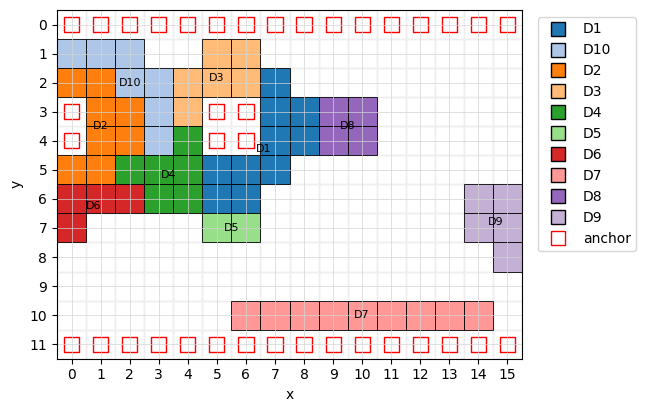

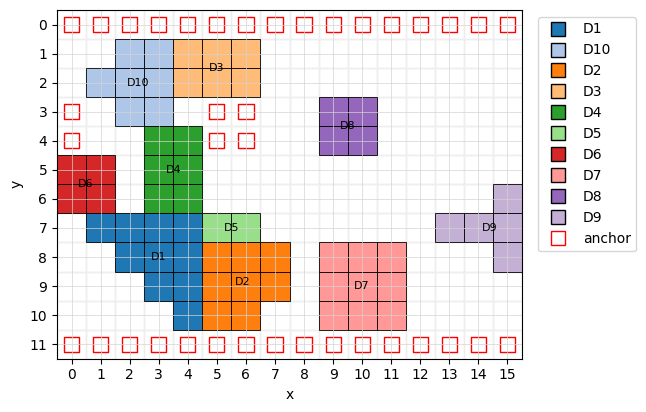

<Axes: xlabel='x', ylabel='y'>

In [6]:
sol = solve_layout_small(usable, anchors, blocks, adj_rules, K=30, rng_seed=7)
plot_layout(sol, usable, anchors)
sol2 = reshape_to_rectangular(sol, usable, anchors)
plot_layout(sol2, usable, anchors)

```markdown
# Define Grid, Anchors, Blocks, and Adjacency Rules

This cell initializes the environment for the block placement problem:

-   `rect_usable(w, h)`: A helper to define a rectangular grid of `w` width and `h` height as the `usable` area for block placement.
-   `usable`: The set of all available cells on the grid.
-   `anchors`: A dictionary defining various anchor points (e.g., "core", "entry", "facade") as sets of specific cells. Blocks can have proximity constraints relative to these anchors.
-   `blocks`: A list of `BlockSpec` objects, each defining a block with its ID, required area, and proximity constraints to anchors.
-   `adj_rules`: A dictionary specifying adjacency rules between pairs of blocks. These can be hard constraints (`MUST_TOUCH`, `MUST_NOT_TOUCH`) or soft preferences.
-   Finally, it calls `solve_layout_small` to find an initial solution and prints whether a solution was found and the area of each placed block.
```

```markdown
# Visualization Function: `plot_layout`

This cell defines the `plot_layout` function, which is a utility for visually representing the grid layout. It uses `matplotlib` to:

-   Draw the overall `usable` grid area.
-   Display each placed block (`placements`) with a unique color and its ID at the centroid.
-   Highlight any defined `anchors`.
-   Add a legend for easy identification of blocks and anchors.

This function is crucial for understanding the output of the block placement solver.
```

```markdown
# Display Initial Solution

This cell checks if `solve_layout_small` found a solution (`sol` is not None). If a solution exists, it calls the `plot_layout` function to visualize the initial arrangement of blocks based on the solver's output. This provides a visual representation of how the solver placed the irregular clusters.
```

```markdown
# Reshape to Rectangular Blocks Function: `reshape_to_rectangular`

This cell introduces the `reshape_to_rectangular` function, which aims to convert the irregularly shaped blocks generated by the solver into more regular, rectangular forms. The function attempts to:

-   Replace each placed cluster with a rectangular cluster of the same area.
-   Prioritize 'squarish' rectangles (where width and height are similar).
-   Maintain proximity to the original cluster's centroid.
-   Search for exact-area rectangles first.
-   If no good exact-area rectangle is found, it looks for slightly larger rectangular areas and then attempts to find a contiguous subset of the required size within them.
-   It ensures that the reshaped rectangles do not overlap with other blocks or anchor cells.

This function helps refine the layout for scenarios where rectangular blocks are preferred or required.
```

```markdown
# Solve and Visualize Initial and Reshaped Layouts

This cell demonstrates the full workflow:

1.  It re-runs `solve_layout_small` to obtain an initial, potentially irregularly shaped, block placement (`sol`).
2.  It then visualizes this initial placement using `plot_layout`.
3.  Next, it calls `reshape_to_rectangular` on the initial solution to obtain a new set of placements (`sol2`) where blocks are reshaped into rectangular forms.
4.  Finally, it visualizes this reshaped layout (`sol2`) using `plot_layout`, allowing for a direct comparison between the solver's output and the optimized rectangular layout.
```